<a href="https://colab.research.google.com/github/HarryKmK13/Data-Mineing-and-analytics-26/blob/main/DMA26_Lab_2_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATA MINING & ANALYTICS (2026)

Make sure you fill in any place that says `YOUR CODE HERE` or `YOUR ANSWER HERE`, as well as your name below:

In [3]:
NAME = "Kyaw Min Khant"

---

# Lab 2: Clustering ##

**Please read the following instructions very carefully.**

## About the Dataset
The dataset for this lab has been created from some custom features from Lab 1. The columns are named as q1, q2....etc. A description of the features can be found at this link: https://docs.google.com/spreadsheets/d/18wwyjGku2HYfgDX9Vez64lGHz31E_PfbpmAdfb7ly6M/edit?usp=sharing

## Working on the assignment / FAQs
- **Always use the seed/random_state as *42* wherever applicable** (This is to ensure repeatability in answers, across students and coding environments).
    - This can typically look like taking in another argument `random_state = 42` when applicable.
- The points allotted per question is listed.
- To avoid any ambiguity, each question also specifies what *value* the function must return. Note that these are dummy values and not the answers themselves.
- If a question has multiple answers (due to differences in handling NaNs, zeros etc.), all answers will be considered.
- Most assignments have bonus questions for extra credit, do try them out!
- You can delete the `raise NotImplementedError()` when you are attempting the question.
- **Submitting the assignment** : Save your work as a PDF (Print -> Save as PDF), download the `.ipynb` file from Colab (Download -> Download as .ipynb), and upload these two files to Gradescope. **Run all cells before submitting.**
- **MAKE A COPY OF THIS FILE FOR YOURSELF TO EDIT/SAVE.**
- That's about it. Happy coding!

In [4]:
import pandas as pd
import collections
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.preprocessing import normalize

import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.style.use('ggplot')


In [5]:
#DOWNLOADING DATASET
!pip install gdown

import gdown

file_id = "1DdDiTIk7tfjljRXiGACphxnF44vrzuag"
url = f"https://drive.google.com/uc?id={file_id}"

# Download yelp reviewers
output = 'yelp_reviewers.csv'
gdown.download(url, output, quiet=False)
print('Dataset Downloaded: yelp_reviewers.csv')
df = pd.read_csv('yelp_reviewers.csv', delimiter= ',')
df = df.sample(frac=0.3, random_state=42)
print(df.dropna().describe())
print('....SETUP COMPLETE....')


Downloading...
From: https://drive.google.com/uc?id=1DdDiTIk7tfjljRXiGACphxnF44vrzuag
To: /content/yelp_reviewers.csv
100%|██████████| 35.8M/35.8M [00:00<00:00, 172MB/s] 


Dataset Downloaded: yelp_reviewers.csv
                q3           q4           q5           q6           q7  \
count  7177.000000  7177.000000  7177.000000  7177.000000  7177.000000   
mean      6.838651     5.281455     4.750871     8.808973     1.539160   
std       7.597977    16.208703    13.866352    19.980443     0.885421   
min       1.000000     1.000000     1.000000     1.000000     0.000000   
25%       3.000000     1.000000     1.000000     2.000000     1.100000   
50%       5.000000     2.000000     2.000000     5.000000     1.610000   
75%       9.000000     4.000000     4.000000     9.000000     2.200000   
max     252.000000   607.000000   474.000000   773.000000     5.530000   

                q8           q9          q10          q11          q12  ...  \
count  7177.000000  7177.000000  7177.000000  7177.000000  7177.000000  ...   
mean      0.934928     0.870281     1.549898    26.732782    25.660616  ...   
std       0.976816     0.950066     1.024145    10.226302

In [6]:
df.head().T

,129451,116706,144394,24699,47453
user_id,kIWQXgjmVdgEs9BOgr8G5A,fXU_-5DBmNlGhI8fbX-2vQ,prF_lbKywPnZhNqvJOOaDw,8GHUeOm807bI5Qh4X3CHBA,Gd_IGX3BmRYbPD84ovLEoA
q3,1,1,1,1,8
q4,0,0,0,0,2
q5,0,0,0,0,1
q6,0,0,0,0,8
q7,0.0,0.0,0.0,0.0,2.08
q8,NaN,NaN,NaN,NaN,0.69
q9,NaN,NaN,NaN,NaN,0.0
q10,NaN,NaN,NaN,NaN,2.08
q11,NaN,NaN,NaN,NaN,18.18


---

### Question 1 `(1 point)`
What is the best choice of k according to the silhouette metric for clustering q4-q6? Only consider 2 <= k <= 8. (hint: take a look at `silhouette_score`).


**NOTE**: For features with high variance, empty clusters can occur. There are several ways of dealing with empty clusters. A common approach is to drop empty clusters. The preferred approach for this lab is to treat the empty clusters as “singletons”, leaving them empty with single point placeholders (so no need to drop anything for the purposes of the lab).

For KMeans use argument **n_init = 10** when applicable, n_init is the number of times the KMeans algorithm is run with different centroid seeds.


In [7]:
#Make sure you return the answer value in this function.
#The return value should be an integer.
def q1(df):

  # YOUR CODE HERE
  # For KMeans use argument n_init = 10 when applicable.
  X = df[['q4', 'q5', 'q6']]

  best_k = None
  best_score = -1
  for k in range(2, 9):
      model = KMeans(n_clusters=k, n_init=10, random_state=42)
      labels = model.fit_predict(X)

      score = silhouette_score(X, labels)

      if score > best_score:
          best_score = score
          best_k = k

  return int(best_k)

print(q1(df))

2


What is the best choice of k?

In [8]:
k = 2

### Question 2 `(1 point)`
The Elbow Method leverages the decreasing trend of within-cluster variation to determine the optimal number of clusters. Calculate the within-cluster variation (Sum of Square Error) for clustering q7-q10. Only consider 2 <=k<= 8. (hint: use the formula from reading 10.2 for SSE)

**Note:** Keep in mind, there may be missing values in this part of the dataset! For these missing values, first find the subset of data specified for this question (q7-q10), then replace the missing values with 0. We do this since the missing values from q7-q10 are most commonly because of taking the log's of values of 0 from q3-q6.

For KMeans use argument **n_init = 10** when applicable.

In [9]:
#Make sure you return the answer value in this function.
#The return value should be a dictionary. Eg : {2:1000,3:500,4:1460} for each number of clusters.(Truncate to integers)
def q2(df):

  # YOUR CODE HERE
  # For KMeans use argument n_init = 10 when applicable.
  X = df[['q7', 'q8', 'q9', 'q10']].fillna(0)

  sse = {}

  for k in range(2, 9):
      model = KMeans(n_clusters=k, n_init=10)
      model.fit(X)

      sse[k] = int(model.inertia_)

  return sse


print(q2(df))

{2: 51341, 3: 35159, 4: 26280, 5: 22137, 6: 19328, 7: 16965, 8: 15577}


In [10]:
#This is an graded cell, do not edit
print(q2(df))

{2: 51341, 3: 35159, 4: 26280, 5: 22137, 6: 19328, 7: 16959, 8: 15453}


### Question 3 `(1 point)`
What is the best choice of k according to the silhouette metric for clustering q11-q13? Only consider 2 <= k <= 8.

**Note:** Keep in mind, there may be missing values in this part of the dataset! For these missing values, first find the subset of data specified for this question (q11-q13), then drop rows that have missing values.

For KMeans use argument **n_init = 10** when applicable

In [11]:
#Make sure you return the answer value in this function.
#The return value should be an integer.
def q3(df):

  # YOUR CODE HERE
  # For KMeans use argument n_init = 10 when applicable.
    X = df[['q11', 'q12', 'q13']].dropna()

    best_k = None
    best_score = -1

    for k in range(2, 9):
        model = KMeans(
            n_clusters=k,
            n_init=10,
            random_state=42
        )

        labels = model.fit_predict(X)
        score = silhouette_score(X, labels)

        if score > best_score:
            best_score = score
            best_k = k

    return int(best_k)

print(q3(df))

8


What is the best choice of k?

In [12]:
# YOUR ANSWER HERE
k = 8

### Question 4 `(1 point)`
Take the best clustering (i.e., best value of K) from Question 3 and using the same subset of data from q11-q13, list the number of data points in each cluster. **Return your answer in dictionary form (i.e. `ans = {0: 100, 1: 200, ...}`).**

For KMeans use argument **n_init = 10** when applicable

In [13]:
#Make sure you return the answer value in this function.
#The return value should be an dictionary. Eg : {0:1000,1:500,2:1460}.
def q4(df):

    # YOUR CODE HERE
    # For KMeans use argument n_init = 10 when applicable.
    X = df[['q11', 'q12', 'q13']].dropna()

    best_k = q3(df)

    model = KMeans(
        n_clusters=best_k,
        n_init=10,
        random_state=42
    )

    labels = model.fit_predict(X)

    counts = {}
    for cluster in range(best_k):
        counts[cluster] = int((labels == cluster).sum())

    return counts

In [14]:
#This is an graded cell, do not edit
print(q4(df))

{0: 9862, 1: 5728, 2: 1228, 3: 1632, 4: 3037, 5: 2108, 6: 4449, 7: 2065}


### Question 5 `(1 point)`
Consider the best clustering from Question 3. Were there clusters that represented very **useful** but **not funny** reviewers (check column definitions for columns corresponding to funny, useful, etc.)?  If so, print the center of that cluster.

For KMeans use argument **n_init = 10** when applicable

In [15]:
#Make sure you return the answer value in this function.
#The return value should be a list. Eg : [10, 30, 54].
def q5(df):

    # YOUR CODE HERE
    # For KMeans use argument n_init = 10 when applicable.
    X = df[['q11', 'q12', 'q13']].dropna()

    best_k = q3(df)

    model = KMeans(
        n_clusters=best_k,
        n_init=10,
        random_state=42
    )
    model.fit(X)

    centers = model.cluster_centers_

    # q11 = useful, q12 = funny
    # Find cluster that is highly useful but not funny
    cluster_index = np.argmax(centers[:, 0] - centers[:, 1])

    return centers[cluster_index].tolist()

In [16]:
#This is a graded cell, do not edit
print(np.round(q5(df), decimals=1, out=None))

[98.2  1.   0.9]


### Question 6 `(1 point)`
Consider the best clustering from Question 3. What was the centroid of the cluster that represented relatively uniform strength in all voting categories?

For KMeans use argument **n_init = 10** when applicable.

In [17]:
#Make sure you return the answer value in this function.
#The return value should be a centroid in list form. Eg : [10, 10.5, 13].
def q6(df):

    # YOUR CODE HERE
    # For KMeans use argument n_init = 10 when applicable.
    X = df[['q11', 'q12', 'q13']].dropna()

    best_k = q3(df)

    model = KMeans(
        n_clusters=best_k,
        n_init=10,
        random_state=42
    )
    model.fit(X)

    centers = model.cluster_centers_

    # Find the centroid with the smallest spread
    # among q11, q12, and q13
    spreads = np.ptp(centers, axis=1)
    cluster_index = np.argmin(spreads)

    return centers[cluster_index].tolist()

In [18]:
#This is a graded cell, do not edit
print(q6(df))

[31.35819374016461, 30.452073789125073, 38.187057177829104]


### Question 7 `(1 point)`
Cluster the dataset using $k = 7$ and using features q7-q15 (refer to the column descriptions if needed).
What is the silhouette metric for this clustering?
For a more in-depth understanding of cluster analysis with silhouette, look [here](http://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html).

As before, fill NaN values in q7-q10 with 0, but drop rows that have NaN values from q11-q15. For KMeans use argument **n_init = 10** when applicable

In [19]:
#Make sure you return the answer value in this function.
#The return value should be a float.
def q7(df):

    # YOUR CODE HERE
    # For KMeans use argument n_init = 10 when applicable.
    X = df[['q7', 'q8', 'q9', 'q10',
            'q11', 'q12', 'q13', 'q14', 'q15']].copy()

    # Fill NaN values in q7-q10 with 0
    X[['q7', 'q8', 'q9', 'q10']] = (
        X[['q7', 'q8', 'q9', 'q10']].fillna(0)
    )

    # Drop rows with NaN values in q11-q15
    X = X.dropna(subset=['q11', 'q12', 'q13', 'q14', 'q15'])

    model = KMeans(
        n_clusters=7,
        n_init=10,
        random_state=42
    )

    labels = model.fit_predict(X)

    return float(silhouette_score(X, labels))

In [20]:
#This is a graded cell, do not edit
print(q7(df))

0.4757489954135929


### Question 8 `(1 point)`
Cluster the dataset using $k = 7$ and using features q7-q15 (refer to the column descriptions if needed).

What is the average q3 value in each of the clusters? Replace/fill NaN values for q7-q15 as you have done for previous questions.

In [21]:
#Make sure you return the answer value in this function.
#The return value should be an Array. Eg : [10, 30, 54].
def q8(df):

    # YOUR CODE HERE
    # For KMeans use argument n_init = 10 when applicable.
    X = df[['q7', 'q8', 'q9', 'q10',
            'q11', 'q12', 'q13', 'q14', 'q15']].copy()

    # Fill NaN values in q7-q10 with 0
    X[['q7', 'q8', 'q9', 'q10']] = (
        X[['q7', 'q8', 'q9', 'q10']].fillna(0)
    )

    # Drop rows with NaN values in q11-q15
    X = X.dropna(subset=['q11', 'q12', 'q13', 'q14', 'q15'])

    # Cluster using k = 7
    model = KMeans(
        n_clusters=7,
        n_init=10,
        random_state=42
    )

    labels = model.fit_predict(X)

    # Keep q3 values corresponding to the rows used for clustering
    q3_values = df.loc[X.index, 'q3']

    # Average q3 for each cluster
    averages = np.array([
        q3_values[labels == cluster].mean()
        for cluster in range(7)
    ])

    return averages

In [22]:
#This is a graded cell, do not edit
print(np.round(q8(df), decimals=1, out=None))

[3.8 3.6 4.8 1.4 4.6 4.6 2.5]


### Question 9 `(2 points)`

We will now cluster the dataset using all features in the dataset.

We can drop features with high incidents of `-inf` / `NaN` / blank values. We will also perform some form of normalization on these features so as not to over bias the clustering towards the larger magnitude features.

Let's go ahead and get started.


#### Data Cleansing and Normalization ####
**Check how many null values there are in each column.**

In [24]:
# YOUR CODE HERE
df.isnull().sum().sort_values(ascending=False)

,0
q9,36743
q8,35280
q10,24338
q12,21383
q11,21383
q13,21383
q16ab,14469
q4,0
q7,0
user_id,0


It looks like q8 - q13 and q16ab have a lot of null values. Let's see what the impact is of removing the two columns with the most null values.

**Drop the two columns with the most NaN values, and then remove all rows with NaN values remaining.**

In [25]:
# YOUR CODE HERE
null_counts = df.isnull().sum()

two_most_null = null_counts.nlargest(2).index

df_clean = df.drop(columns=two_most_null).dropna()

print(two_most_null.tolist())
print(df_clean.shape)

['q9', 'q8']
(19582, 41)


By removing two features, we have effectively doubled the number of rows remaining than if we just removed all rows with a NaN value. That's pretty good.  

Now, let's preprocess categorical variables into dummy variables. (hint: look at `pd.get_dummies`).

In [26]:
# YOUR CODE HERE
# Remove the identifier column
df_features = df_clean.drop(columns=['user_id'])

# Convert categorical variables to dummy variables
df_encoded = pd.get_dummies(df_features)

print(df_encoded.shape)
df_encoded.head()

(19582, 42)


,q3,q4,q5,q6,q7,q10,q11,q12,q13,q14,...,q16x,q16y,q16z,q16aa,q16ab,q16ac,q16s_experienced,q16s_freshman,q16t_no,q16t_yes
47453,8,2,1,8,2.08,2.08,18.18,9.09,72.73,10,...,0.001755,91.072917,4,0,1.00,4.875,True,False,True,False
53000,2,1,1,2,0.69,0.69,25.00,25.00,50.00,10,...,0.000000,46.500000,0,3,0.00,3.000,True,False,True,False
64580,1,0,0,1,0.00,0.00,0.00,0.00,100.00,5,...,0.000498,197.000000,0,0,0.00,5.000,True,False,True,False
84662,5,0,0,4,1.61,1.39,0.00,0.00,100.00,6,...,0.001578,167.000000,1,0,1.25,3.600,True,False,True,False
50079,8,8,5,13,2.08,2.56,30.77,19.23,50.00,9,...,0.009861,91.552083,1,13,4.00,3.750,True,False,True,False


Now, normalize the remaining values.

In [28]:
# YOUR CODE HERE
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_normalized = scaler.fit_transform(df_encoded)

print(X_normalized.shape)

(19582, 42)


Using the the "sum of squared errors" metric along with the elbow method (make a graph and visually examine for the elbow), what is the best k to use for this dataset? (Hint: look at the `inertia_` attribute for k-means in sklearn).

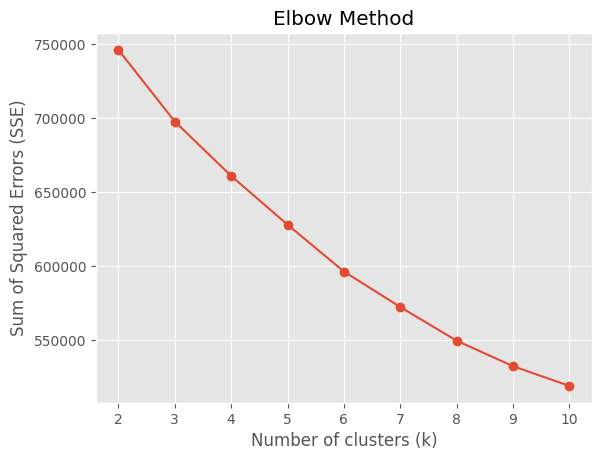

{2: 746305.866188709, 3: 697906.7937385784, 4: 661151.2282062835, 5: 628213.7358065, 6: 596559.2814867815, 7: 572564.1312791617, 8: 549818.4077918557, 9: 532584.6884870357, 10: 519241.24719893036}


In [29]:
# The return value should be a graph to visualize the elbow method and the value of k determined from that graph.

# YOUR CODE HERE
# For KMeans use argument n_init = 10 when applicable.
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse = []

k_values = range(2, 11)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )
    model.fit(X_normalized)
    sse.append(model.inertia_)

plt.plot(k_values, sse, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method')
plt.xticks(k_values)
plt.show()

print(dict(zip(k_values, sse)))

**Answer: YOUR ANSWER HERE**
k = 6




### Question 10 `(1 points)`
This question is conceptual. List the **two main metrics** used to find the optimal k for K-Means clustering.
1. Compare what each of these two metrics measure. *Include unique properties and vulnerabilities of each metric.*  
2. Describe one scenario where a data scientist would prefer using one metric over the other.

Hint: Consider how graph trends, data scale, and data size might impact each metric.


**Answer:** YOUR ANSWER HERE

1. SSE / Elbow Method: SSE measures how close each data point is to the centroid of its assigned cluster. Lower SSE means the clusters are more compact. As k increases, SSE will always decrease, so the goal is to look for an “elbow” where adding more clusters gives only small improvements. Its main weakness is that the elbow can be subjective or unclear. SSE is also sensitive to feature scale, so normalization is important.
2. Silhouette Score: The silhouette score measures both how similar a point is to its own cluster and how different it is from neighboring clusters. Scores range from -1 to 1, with higher values indicating better-separated clusters. Unlike SSE, it gives a more direct measure of cluster quality, but it can be computationally expensive on large datasets because it depends on distances between many data points. It can also perform poorly when clusters have unusual shapes or very different densities.

## Bonus question (`2 Points`) - Reviewer overlap:

Now, let's take a look back at what we were doing last week, and use that in junction with what we've learned from above today.

For this bonus question, please:
- Download last week's dataset
- Aggregate cool, funny, and useful votes for each business id
- You may transform the aggregations (take %, log, or leave it as it is)
- Cluster this dataframe (you can choose k). Do you find any meaningful/interesting clusters?
- Assign the cluster label to each business id
- Merge this with users to show what clusters the reviewers have reviewed.


**You should be returning a dataframe with the following structure in the end:**

Rows: user IDs as indices.

Columns: boolean columns describing if the user ID has a review for each of the labels determined from the K-Means clustering, a boolean column describing if the user ID has a review for all of the given labels, and a column composing of lists of cluster IDs that the given user ID has written reviews for.

For KMeans use argument n_init=10 when applicable.

In [33]:
# YOUR CODE HERE
# For KMeans use argument n_init = 10 when applicable.

import pandas as pd
import numpy as np
import gdown

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# 1. Download last week's Yelp review dataset

file_id = "1bFo3LSsYo6jhs805f91AArkQYETwGgkc"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "yelp_reviews.csv", quiet=False)

reviews = pd.read_csv("yelp_reviews.csv")


# 2. Aggregate cool, funny, and useful votes
#    for each business

vote_cols = ['cool_votes', 'funny_votes', 'useful_votes']

reviews[vote_cols] = (
    reviews[vote_cols]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
)

business_votes = (
    reviews
    .groupby('business_id')[vote_cols]
    .sum()
)


# 3. Transform and normalize
# Vote totals are highly skewed, so use log transformation
X = np.log1p(business_votes[vote_cols])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Cluster businesses

k = 4

kmeans = KMeans(
    n_clusters=k,
    n_init=10,
    random_state=42
)

business_votes['cluster'] = kmeans.fit_predict(X_scaled)


# 5. Look at the clusters


business_votes['total_votes'] = (
    business_votes['cool_votes']
    + business_votes['funny_votes']
    + business_votes['useful_votes']
)

cluster_summary = (
    business_votes
    .groupby('cluster')
    .agg(
        number_of_businesses=('total_votes', 'size'),
        median_cool=('cool_votes', 'median'),
        median_funny=('funny_votes', 'median'),
        median_useful=('useful_votes', 'median'),
        mean_total_votes=('total_votes', 'mean')
    )
    .round(2)
)

print(cluster_summary)


# 6. Assign each review its business cluster


review_clusters = (
    reviews[['user_id', 'business_id']]
    .merge(
        business_votes[['cluster']],
        left_on='business_id',
        right_index=True,
        how='inner'
    )
)


# One user only needs to appear once per cluster
user_cluster_pairs = (
    review_clusters[['user_id', 'cluster']]
    .drop_duplicates()
)

# 7. Create boolean columns for each cluster


cluster_flags = pd.crosstab(
    user_cluster_pairs['user_id'],
    user_cluster_pairs['cluster']
).astype(bool)

# Make sure every cluster 0...k-1 exists
cluster_flags = cluster_flags.reindex(
    columns=range(k),
    fill_value=False
)

cluster_flags.columns = [
    f'cluster_{i}' for i in range(k)
]


# 8. Create list of clusters reviewed by each user

cluster_lists = (
    user_cluster_pairs
    .groupby('user_id')['cluster']
    .apply(lambda x: sorted(x.unique().tolist()))
    .rename('cluster_ids')
)


# 9. Combine everything


result = cluster_flags.join(cluster_lists)

# Boolean: has this reviewer reviewed businesses
# from every cluster?
cluster_columns = [f'cluster_{i}' for i in range(k)]

result['all_clusters'] = result[cluster_columns].all(axis=1)


# 10. Merge with the current reviewer/user dataset

all_users = pd.Index(df['user_id'].unique(), name='user_id')

result = result.reindex(all_users)

result[cluster_columns] = (
    result[cluster_columns]
    .fillna(False)
    .astype(bool)
)

result['all_clusters'] = (
    result['all_clusters']
    .fillna(False)
    .astype(bool)
)

result['cluster_ids'] = result['cluster_ids'].apply(
    lambda x: x if isinstance(x, list) else []
)
bonus_df = result
bonus_df.head()

Downloading...
From (original): https://drive.google.com/uc?id=1bFo3LSsYo6jhs805f91AArkQYETwGgkc
From (redirected): https://drive.google.com/uc?id=1bFo3LSsYo6jhs805f91AArkQYETwGgkc&confirm=t&uuid=3774d443-a93c-42dd-a2dc-7353d421f6c5
To: /content/yelp_reviews.csv
100%|██████████| 377M/377M [00:02<00:00, 144MB/s]


         number_of_businesses  median_cool  median_funny  median_useful  \
cluster                                                                   
0                       12643          1.0           1.0            4.0   
1                        5836          6.0           5.0           13.0   
2                       23130          0.0           0.0            0.0   
3                        1708         41.0          34.0           72.0   

         mean_total_votes  
cluster                    
0                    6.80  
1                   29.26  
2                    0.75  
3                  324.65  


,cluster_0,cluster_1,cluster_2,cluster_3,cluster_ids,all_clusters
user_id,,,,,,
kIWQXgjmVdgEs9BOgr8G5A,False,False,False,True,[3],False
fXU_-5DBmNlGhI8fbX-2vQ,False,False,False,True,[3],False
prF_lbKywPnZhNqvJOOaDw,False,False,False,True,[3],False
8GHUeOm807bI5Qh4X3CHBA,False,False,False,True,[3],False
Gd_IGX3BmRYbPD84ovLEoA,True,True,False,True,"[0, 1, 3]",False


In [34]:
#This is a graded cell, do not edit
print(bonus_df.head())

                        cluster_0  cluster_1  cluster_2  cluster_3  \
user_id                                                              
kIWQXgjmVdgEs9BOgr8G5A      False      False      False       True   
fXU_-5DBmNlGhI8fbX-2vQ      False      False      False       True   
prF_lbKywPnZhNqvJOOaDw      False      False      False       True   
8GHUeOm807bI5Qh4X3CHBA      False      False      False       True   
Gd_IGX3BmRYbPD84ovLEoA       True       True      False       True   

                       cluster_ids  all_clusters  
user_id                                           
kIWQXgjmVdgEs9BOgr8G5A         [3]         False  
fXU_-5DBmNlGhI8fbX-2vQ         [3]         False  
prF_lbKywPnZhNqvJOOaDw         [3]         False  
8GHUeOm807bI5Qh4X3CHBA         [3]         False  
Gd_IGX3BmRYbPD84ovLEoA   [0, 1, 3]         False  


*ⓒ Prof. Zachary Pardos, 2022*